<a href="https://colab.research.google.com/github/SinhaPushkar047/ML_Learning_Projects/blob/main/02-Indian-Household-Price/HouseHold_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [425]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.express as px

In [426]:
pd.set_option('display.max_columns',None)

In [427]:
house=pd.read_csv('https://raw.githubusercontent.com/SinhaPushkar047/ML_Learning_Projects/refs/heads/main/02-Indian-Household-Price/House%20Price%20India.csv').drop(columns=['id','Date'])

# **EDA**

In [428]:
house.describe()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,14620.000000,14620.000000,14620.000000,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,3.379343,2.129583,2098.262996,1.509328e+04,1.502360,0.007661,0.233105,3.430506,7.682421,1801.783926,296.479070,1970.926402,90.924008,122033.062244,52.792848,-114.404007,1996.702257,12753.500068,2.012244,64.950958,5.389322e+05
std,0.938719,0.769934,928.275721,3.791962e+04,0.540239,0.087193,0.766259,0.664151,1.175033,833.809963,448.551409,29.493625,416.216661,19.082418,0.137522,0.141326,691.093366,26058.414467,0.817284,8.936008,3.675324e+05
min,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,4.000000,370.000000,0.000000,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,3.000000,1.750000,1440.000000,5.010750e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1200.000000,0.000000,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.750000,1.000000,57.000000,3.200000e+05
50%,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1580.000000,0.000000,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2240.000000,580.000000,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [429]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   number of bedrooms                     14620 non-null  int64  
 1   number of bathrooms                    14620 non-null  float64
 2   living area                            14620 non-null  int64  
 3   lot area                               14620 non-null  int64  
 4   number of floors                       14620 non-null  float64
 5   waterfront present                     14620 non-null  int64  
 6   number of views                        14620 non-null  int64  
 7   condition of the house                 14620 non-null  int64  
 8   grade of the house                     14620 non-null  int64  
 9   Area of the house(excluding basement)  14620 non-null  int64  
 10  Area of the basement                   14620 non-null  int64  
 11  Bu

In [430]:
house.duplicated().sum()

np.int64(0)

In [431]:
corr = house.corr(numeric_only=True)
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto"
)
fig.show()

In [432]:
house['grade of the house'].value_counts()

,count
grade of the house,
7,6011
8,4137
9,1828
6,1324
10,804
11,280
5,154
12,55
4,17


In [433]:
house['number of bedrooms'].value_counts()

,count
number of bedrooms,
3,6612
4,4724
2,1844
5,1079
6,176
1,136
7,30
8,11
9,3


In [434]:
house['number of bathrooms'].value_counts()

,count
number of bathrooms,
2.50,3678
1.00,2509
1.75,2062
2.25,1378
2.00,1323
1.50,968
2.75,831
3.00,510
3.50,504


<Axes: xlabel='living area', ylabel='Count'>

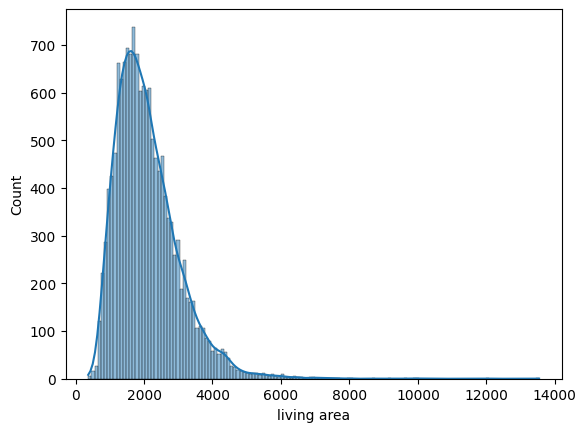

In [435]:
sns.histplot(house['living area'],kde=True)

<Axes: xlabel='lot area', ylabel='Count'>

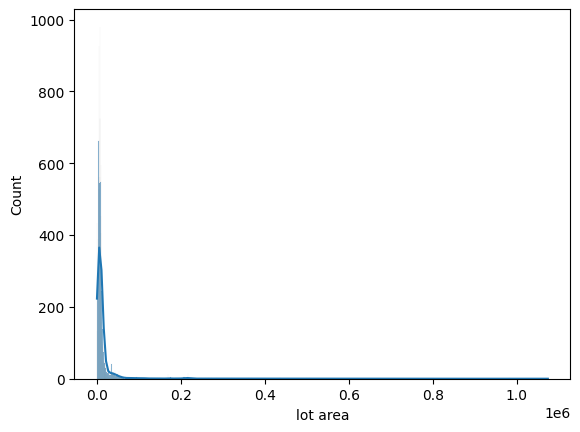

In [436]:
sns.histplot(house['lot area'],kde=True)

<Axes: xlabel='number of floors', ylabel='Count'>

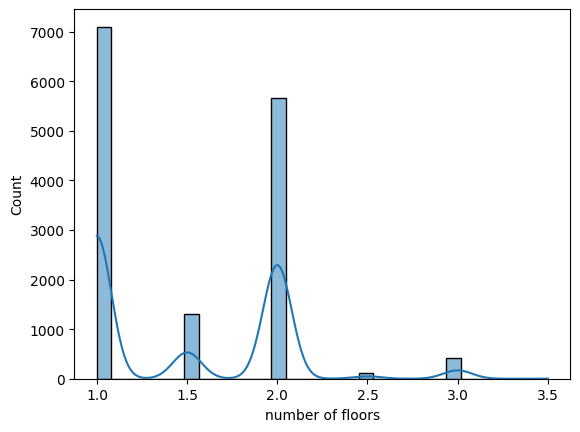

In [437]:
sns.histplot(house['number of floors'],kde=True)

<Axes: xlabel='Area of the house(excluding basement)', ylabel='Count'>

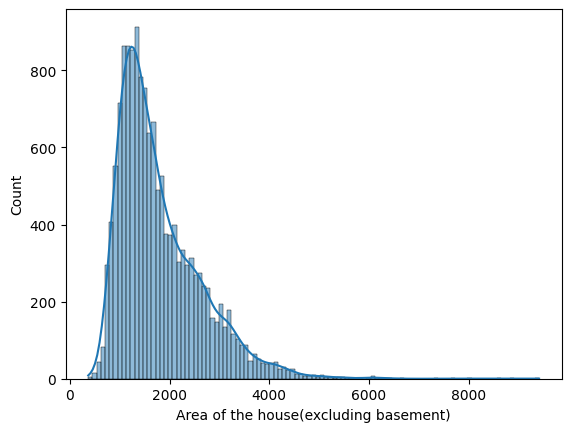

In [438]:
sns.histplot(house['Area of the house(excluding basement)'],kde=True)

<Axes: xlabel='Area of the basement', ylabel='Count'>

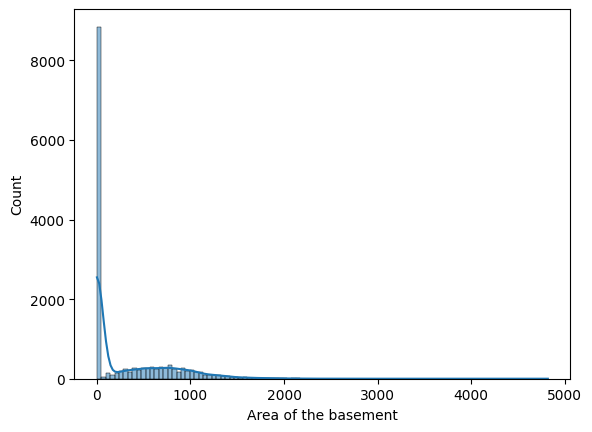

In [439]:
sns.histplot(house['Area of the basement'],kde=True)

<Axes: xlabel='Built Year', ylabel='Count'>

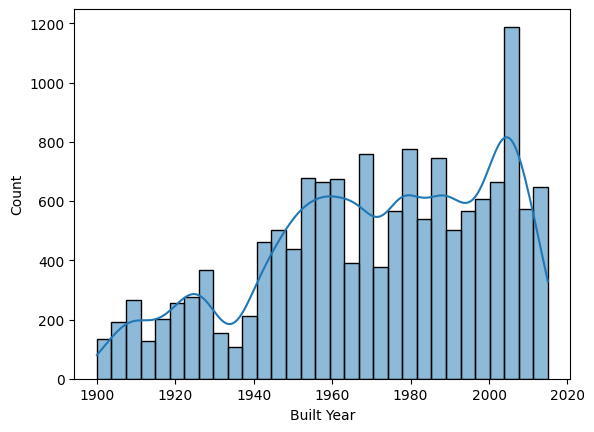

In [440]:
sns.histplot(house['Built Year'],kde=True)

<Axes: xlabel='living_area_renov', ylabel='Count'>

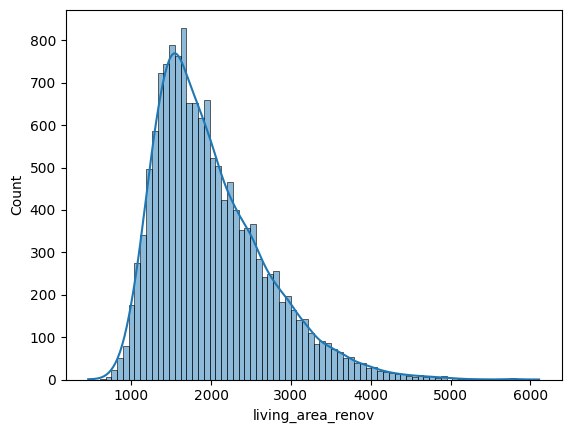

In [441]:
sns.histplot(house['living_area_renov'],kde=True)

<Axes: xlabel='lot_area_renov', ylabel='Count'>

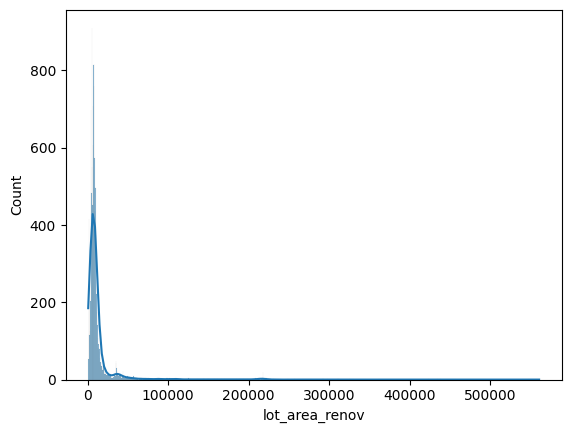

In [442]:
sns.histplot(house['lot_area_renov'],kde=True)

<Axes: xlabel='number of bedrooms', ylabel='Price'>

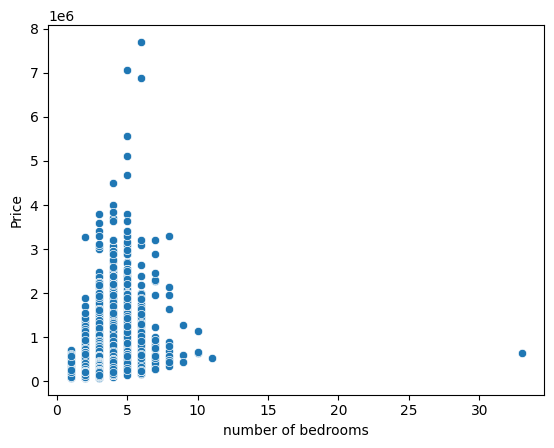

In [443]:
sns.scatterplot(x=house['number of bedrooms'],y=house['Price'])

<Axes: xlabel='number of bathrooms', ylabel='Price'>

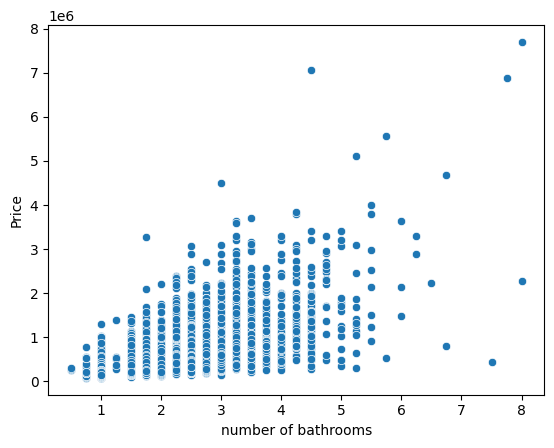

In [444]:
sns.scatterplot(x=house['number of bathrooms'],y=house['Price'])

<Axes: xlabel='living area', ylabel='Price'>

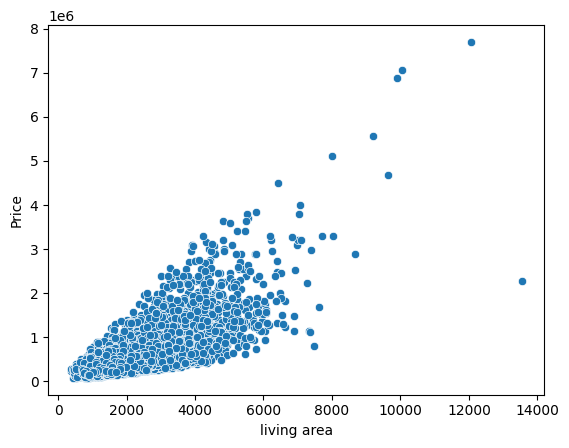

In [445]:
sns.scatterplot(x=house['living area'],y=house['Price'])

<Axes: xlabel='lot area', ylabel='Price'>

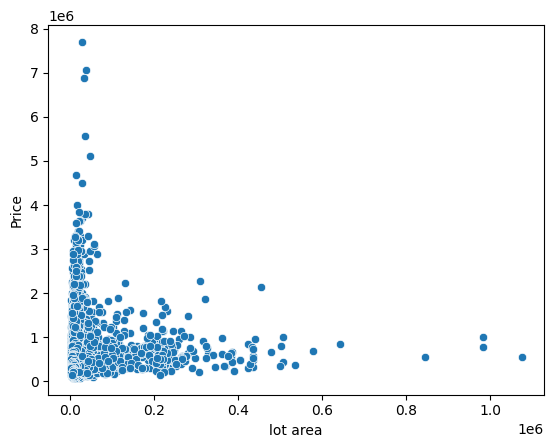

In [446]:
sns.scatterplot(x=house['lot area'],y=house['Price'])

<Axes: xlabel='None', ylabel='Price'>

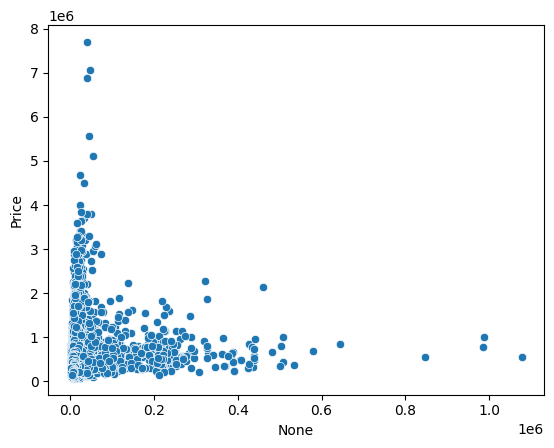

In [447]:
sns.scatterplot(x=(house['living area']+house['lot area']),y=house['Price'])

In [448]:
house

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,5,2.50,3650,9050,2.0,0,4,5,10,3370,280,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,4,2.50,2920,4000,1.5,0,0,5,8,1910,1010,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,5,2.75,2910,9480,1.5,0,0,3,8,2910,0,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,4,2.50,3310,42998,2.0,0,0,3,9,3310,0,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,3,2.00,2710,4500,1.5,0,0,4,8,1880,830,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14615,2,1.50,1556,20000,1.0,0,0,4,7,1556,0,1957,0,122066,52.6191,-114.472,2250,17286,3,76,221700
14616,3,2.00,1680,7000,1.5,0,0,4,7,1680,0,1968,0,122072,52.5075,-114.393,1540,7480,3,59,219200
14617,2,1.00,1070,6120,1.0,0,0,3,6,1070,0,1962,0,122056,52.7289,-114.507,1130,6120,2,64,209000
14618,4,1.00,1030,6621,1.0,0,0,4,6,1030,0,1955,0,122042,52.7157,-114.411,1420,6631,3,54,205000


# **Outlier**

In [449]:
cols=[col for col in house.columns if col not in ['Price']]

In [450]:
q1 = house[cols].quantile(0.25)
q3 = house[cols].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_count = (
    (house[cols] < lower) |
    (house[cols] > upper)
).sum()

outlier_count.sort_values(ascending=False)

,0
lot area,1652
lot_area_renov,1517
number of views,1422
grade of the house,1320
Renovation Year,666
Area of the house(excluding basement),402
living area,395
number of bathrooms,379
number of bedrooms,361
living_area_renov,338


In [451]:
important_cols = [
    "lot area",
    "lot_area_renov",
    "number of views",
    "grade of the house",
    "Renovation Year",
    "Area of the house(excluding basement)",
    "living area",
    "number of bathrooms",
    "number of bedrooms",
    "living_area_renov",
    "Area of the basement",
    "Longitude",
    "waterfront present",
    "condition of the house",
    "Lattitude"
]

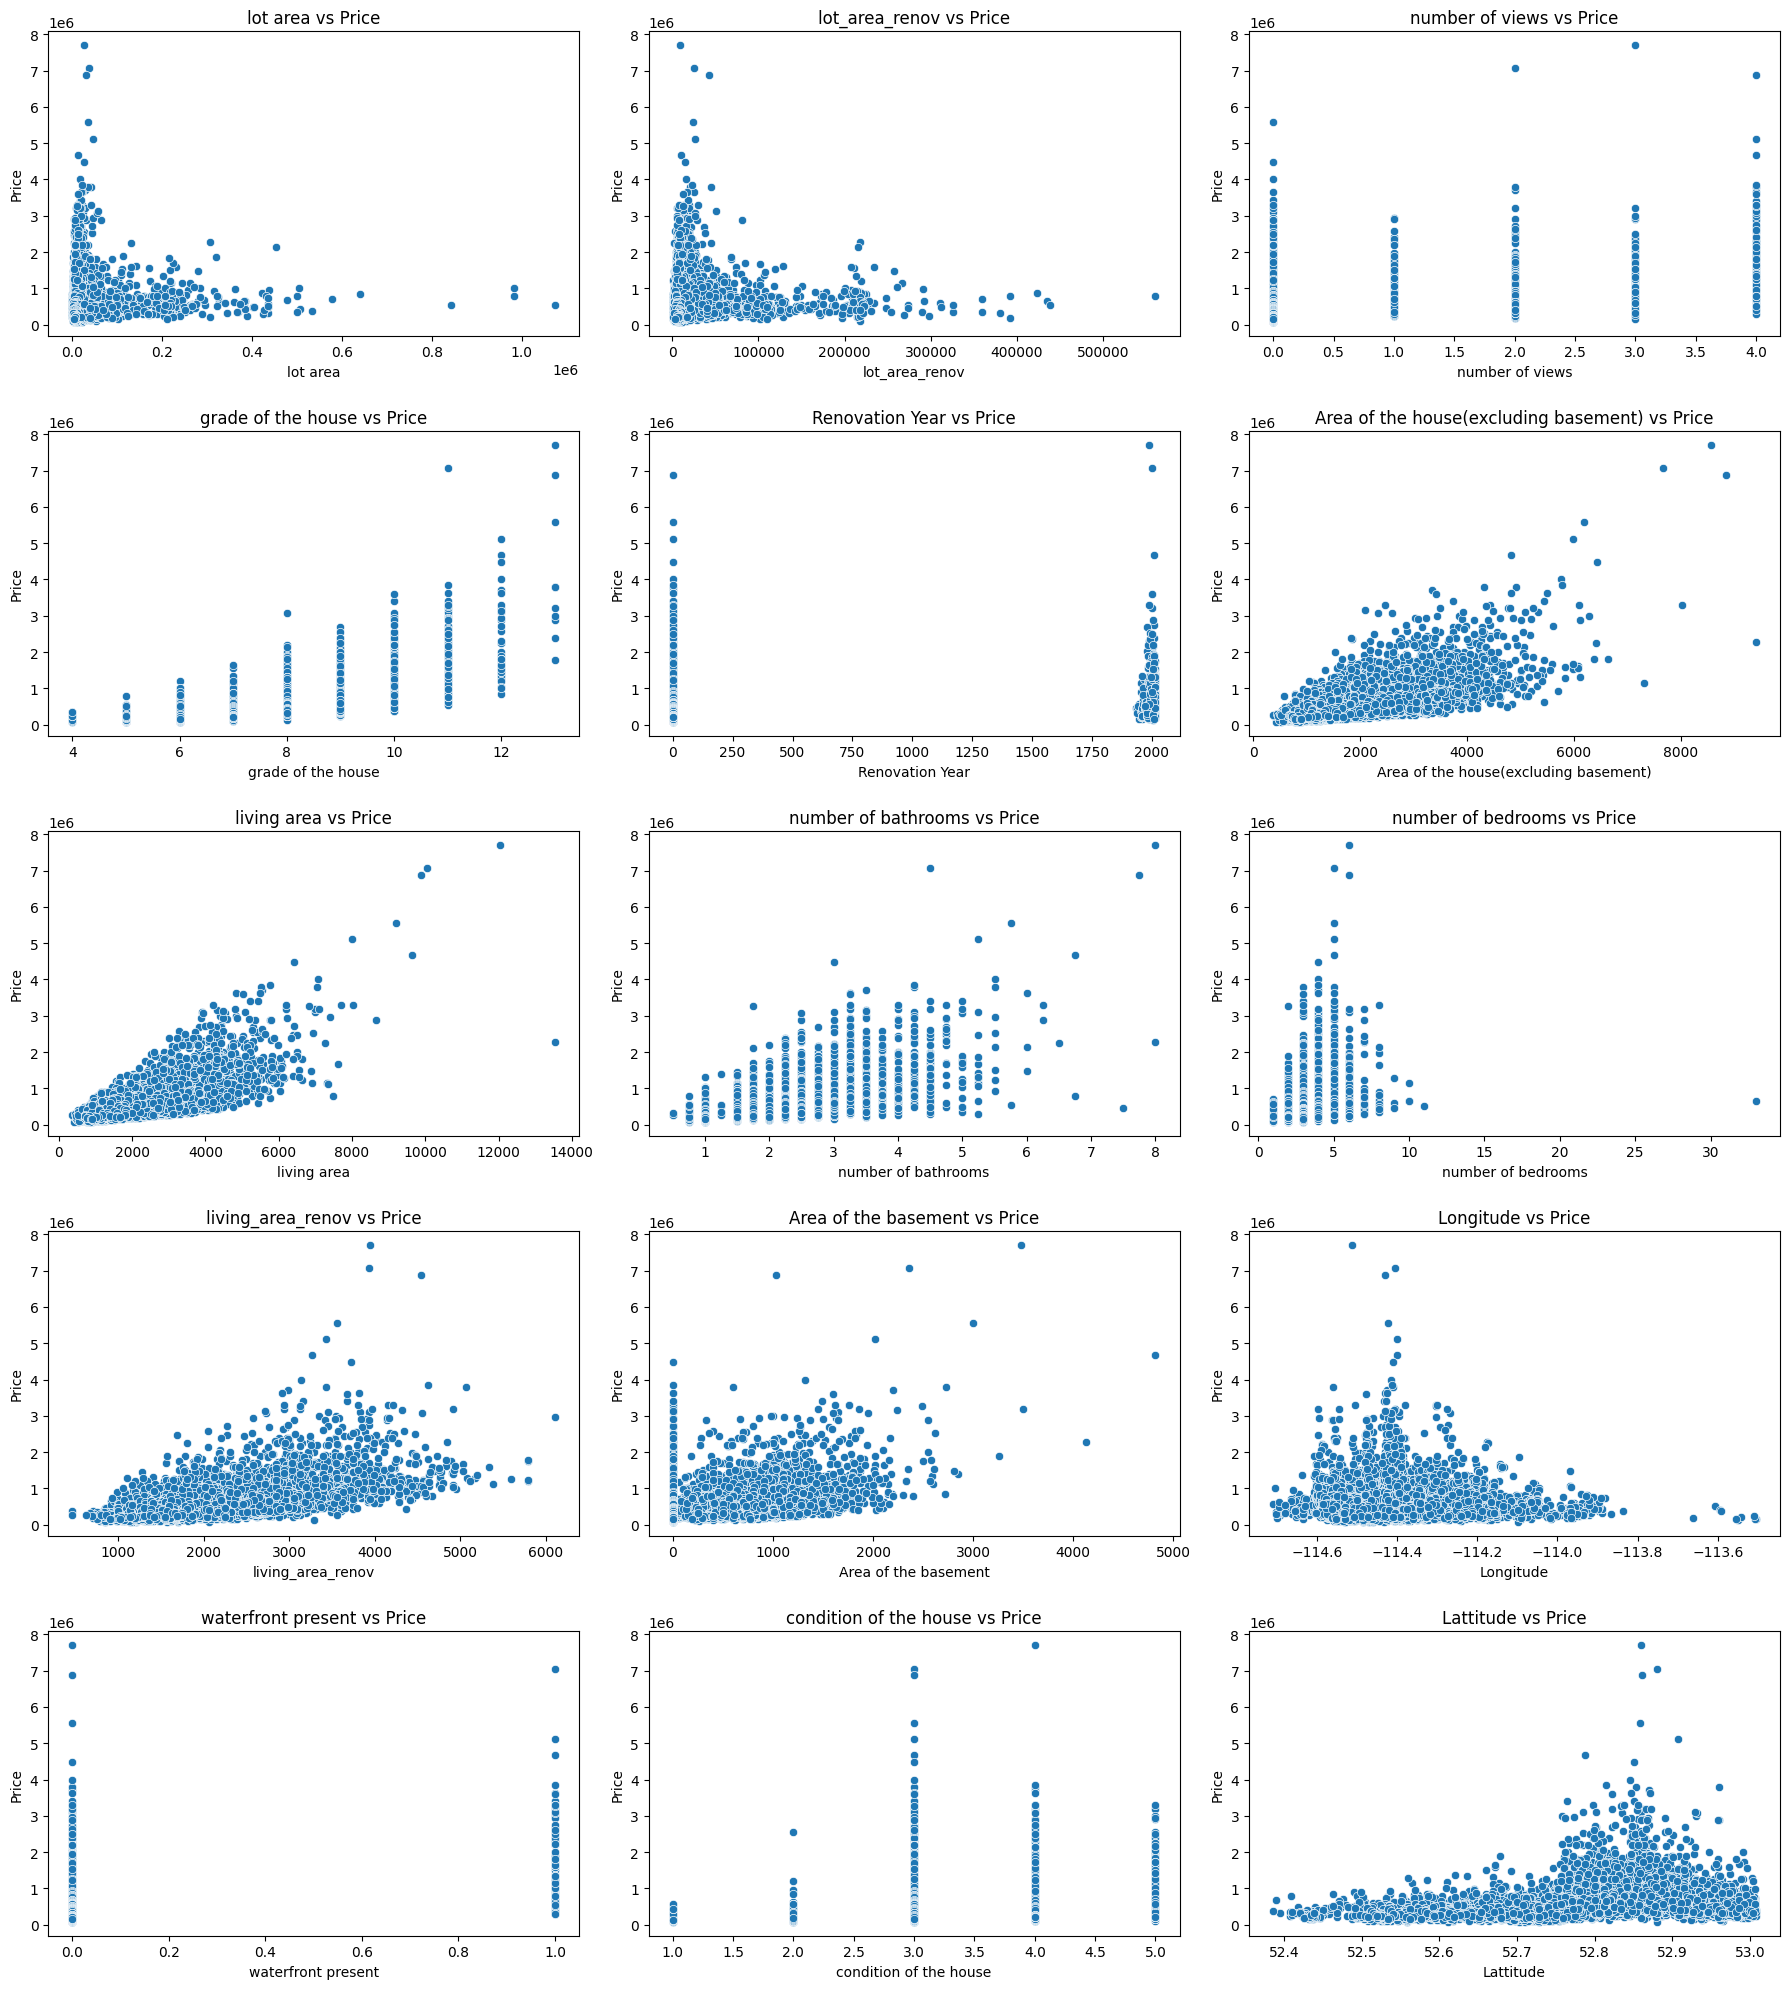

In [452]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))

for col, ax in zip(important_cols, axes.flat):
    sns.scatterplot(data=house, x=col, y='Price', ax=ax)
    ax.set_title(f'{col} vs Price')

plt.tight_layout()
plt.show()

In [469]:
from sklearn.linear_model import LinearRegression
import numpy as np

def find_relationship_outliers(df, feature, target='Price', n=10):

    X = df[[feature]]
    y = df[target]

    model = LinearRegression()
    model.fit(X, y)

    prediction = model.predict(X)

    residual = y - prediction

    result = df[[feature, target]].copy()
    result['prediction'] = prediction
    result['residual'] = residual
    result['abs_residual'] = abs(residual)

    return result.sort_values(
        'abs_residual',
        ascending=False
    ).head(n)

In [470]:
find_relationship_outliers(house, 'living area')

,living area,Price,prediction,residual,abs_residual
10503,12050,7700000,3.345017e+06,4.354983e+06,4.354983e+06
2424,10040,7060000,2.778259e+06,4.281741e+06,4.281741e+06
9171,9890,6890000,2.735964e+06,4.154036e+06,4.154036e+06
6244,9200,5570000,2.541405e+06,3.028595e+06,3.028595e+06
10915,8010,5110000,2.205861e+06,2.904139e+06,2.904139e+06
2907,6430,4490000,1.760349e+06,2.729651e+06,2.729651e+06
8692,4830,3640000,1.309198e+06,2.330802e+06,2.330802e+06
8691,5510,3800000,1.500938e+06,2.299062e+06,2.299062e+06
12442,5770,3850000,1.574250e+06,2.275750e+06,2.275750e+06
12599,5020,3600000,1.362773e+06,2.237227e+06,2.237227e+06


# **PreProcessing**

In [453]:
scale_col=[col for col in house.columns if col not in ['Price']]

In [454]:
trf_col=['living area','lot area','Area of the house(excluding basement)','Area of the basement','Built Year','living_area_renov','lot_area_renov']

In [455]:
pipe=Pipeline([
    ('scale',RobustScaler())
])
pipe1=Pipeline([
    ('trf',PowerTransformer())
])

In [456]:
trf=ColumnTransformer([
    ('scale',pipe,scale_col),
    ('trf',pipe1,trf_col)
])

# **Train Test Split & fitting transformer**

In [457]:
x_train,x_test,y_train,y_test= train_test_split(
    house.drop(columns='Price'),house['Price'],test_size=0.2,random_state=42)

In [458]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

# **Model Train**

In [459]:
lr=LinearRegression()

In [460]:
lr.fit(x_train_trf,y_train)

LinearRegression()

In [461]:
y_predict=lr.predict(x_test_trf)

# **Checking Accuracy**

In [462]:
r2=r2_score(y_test,y_predict)
print('R2: ',r2*100)

R2:  75.11420035457688


In [464]:
score=cross_val_score(
    lr,
    x_train_trf,y_train,
    cv=5,
    scoring='r2'
)
print('CV Score: ',score*100)
print('Mean R2: ',score.mean()*100)

CV Score:  [71.71825423 71.526268   73.95723488 71.58533635 72.17481645]
Mean R2:  72.19238198391145


In [466]:
print('MAE',mean_absolute_error(y_test,y_predict))
print('RMSE',mean_squared_error(y_test,y_predict)**0.5)

MAE 117893.26662557504
RMSE 187266.67520339118


# **Prediction V/S Actual Graph**

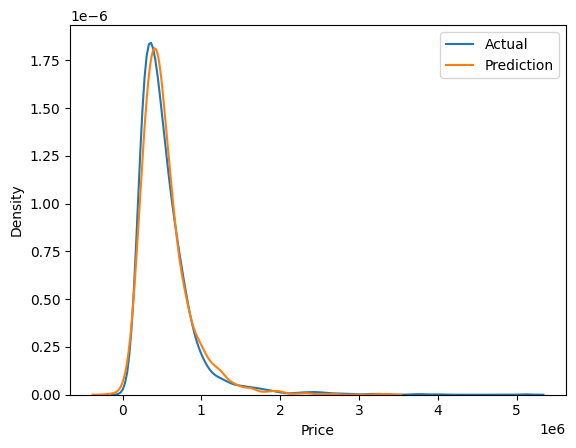

In [468]:
sns.kdeplot(y_test,label='Actual')
sns.kdeplot(y_predict,label='Prediction')
plt.legend()
plt.show()